# Topic: Multiple linear regression

## Due on April 29 at 11:59 pm CT

Instructions:

1. Each question contains equal points (20X5 = 100 points)

2. Submit your work using the link provided in Blackboard for Final Project/Exam.

3. Name your submission as follows: YourFirstName\_CourseCode\_Final-Project-Exam.FileExtension

## Project Name: Grading the professor

Many college courses conclude by giving students the opportunity to evaluate the course and the instructor anonymously. However, the use of these student evaluations as an indicator of course quality and teaching effectiveness is often criticized because these measures may reflect the influence of non-teaching related characteristics, such as the physical appearance of the instructor. The article titled, "Beauty in the classroom: instructors' pulchritude and putative pedagogical productivity" (Hamermesh and Parker, 2005) found that instructors who are viewed to be better looking receive higher instructional ratings. (Daniel S. Hamermesh, Amy Parker, Beauty in the classroom: instructors pulchritude and putative pedagogical productivity, *Economics of Education Review*, Volume 24, Issue 4, August 2005, Pages 369-376, ISSN 0272-7757, 10.1016/j.econedurev.2004.07.013. http://www.sciencedirect.com/science/article/pii/S0272775704001165.)

In this lab we will analyze the data from this study in order to learn what goes into a positive professor evaluation.

## The data

The data were gathered from end of semester student evaluations for a large sample of professors from the University of Texas at Austin. In addition, six students rated the professors' physical appearance. (This is a slightly modified version of the original data set that was released as part of the replication data for *Data Analysis Using Regression and Multilevel/Hierarchical Models* (Gelman and Hill, 2007).) The result is a data frame where each row contains a different course and columns represent variables about the courses and professors

variable         | description
---------------- | -----------
`score`          | average professor evaluation score: (1) very unsatisfactory - (5) excellent.
`rank`           | rank of professor: teaching, tenure track, tenured.
`ethnicity`      | ethnicity of professor: not minority, minority.
`gender`         | gender of professor: female, male.
`language`       | language of school where professor received education: english or non-english.
`age`            | age of professor.
`cls_perc_eval`  | percent of students in class who completed evaluation.
`cls_did_eval`   | number of students in class who completed evaluation.
`cls_students`   | total number of students in class.
`cls_level`      | class level: lower, upper.
`cls_profs`      | number of professors teaching sections in course in sample: single, multiple.
`cls_credits`    | number of credits of class: one credit (lab, PE, etc.), multi credit.
`bty_f1lower`    | beauty rating of professor from lower level female: (1) lowest - (10) highest.
`bty_f1upper`    | beauty rating of professor from upper level female: (1) lowest - (10) highest.
`bty_f2upper`    | beauty rating of professor from second upper level female: (1) lowest - (10) highest.
`bty_m1lower`    | beauty rating of professor from lower level male: (1) lowest - (10) highest.
`bty_m1upper`    | beauty rating of professor from upper level male: (1) lowest - (10) highest.
`bty_m2upper`    | beauty rating of professor from second upper level male: (1) lowest - (10) highest.
`bty_avg`        | average beauty rating of professor.
`pic_outfit`     | outfit of professor in picture: not formal, formal.
`pic_color`      | color of professor's picture: color, black & white.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

##Importing the Relevant Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


from statsmodels.formula.api import ols


# Load data
evals_data = pd.read_csv('/content/evals.csv')

In [ ]:
evals_data.info()
evals_data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   course_id      463 non-null    int64  
 1   prof_id        463 non-null    int64  
 2   score          463 non-null    float64
 3   rank           463 non-null    object 
 4   ethnicity      463 non-null    object 
 5   gender         463 non-null    object 
 6   language       463 non-null    object 
 7   age            463 non-null    int64  
 8   cls_perc_eval  463 non-null    float64
 9   cls_did_eval   463 non-null    int64  
 10  cls_students   463 non-null    int64  
 11  cls_level      463 non-null    object 
 12  cls_profs      463 non-null    object 
 13  cls_credits    463 non-null    object 
 14  bty_f1lower    463 non-null    int64  
 15  bty_f1upper    463 non-null    int64  
 16  bty_f2upper    463 non-null    int64  
 17  bty_m1lower    463 non-null    int64  
 18  bty_m1uppe

,course_id,prof_id,score,rank,ethnicity,gender,language,age,cls_perc_eval,cls_did_eval,...,cls_credits,bty_f1lower,bty_f1upper,bty_f2upper,bty_m1lower,bty_m1upper,bty_m2upper,bty_avg,pic_outfit,pic_color
count,463.000000,463.000000,463.000000,463,463,463,463,463.000000,463.000000,463.000000,...,463,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463,463
unique,NaN,NaN,NaN,3,2,2,2,NaN,NaN,NaN,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,tenured,not minority,male,english,NaN,NaN,NaN,...,multi credit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not formal,color
freq,NaN,NaN,NaN,253,399,268,435,NaN,NaN,NaN,...,436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,386,385
mean,232.000000,45.153348,4.174730,NaN,NaN,NaN,NaN,48.365011,74.427788,36.624190,...,NaN,3.963283,5.019438,5.213823,3.412527,4.146868,4.751620,4.417844,NaN,NaN
std,133.800847,27.547052,0.543865,NaN,NaN,NaN,NaN,9.802742,16.756311,45.018481,...,NaN,1.873936,1.934437,2.018224,1.637102,2.110586,1.575266,1.527380,NaN,NaN
min,1.000000,1.000000,2.300000,NaN,NaN,NaN,NaN,29.000000,10.416670,5.000000,...,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.667000,NaN,NaN
25%,116.500000,20.000000,3.800000,NaN,NaN,NaN,NaN,42.000000,62.696165,15.000000,...,NaN,2.000000,4.000000,4.000000,2.000000,3.000000,4.000000,3.167000,NaN,NaN
50%,232.000000,43.000000,4.300000,NaN,NaN,NaN,NaN,48.000000,76.923080,23.000000,...,NaN,4.000000,5.000000,5.000000,3.000000,4.000000,5.000000,4.333000,NaN,NaN
75%,347.500000,70.500000,4.600000,NaN,NaN,NaN,NaN,57.000000,87.249170,40.000000,...,NaN,5.000000,7.000000,6.000000,5.000000,5.000000,6.000000,5.500000,NaN,NaN


## Exploring the data

<div class = 'exercise'>
<h4>Exercise 1</h4>
Describe the distribution of <code>score</code>. Is the distribution skewed? What does that tell you about how students rate courses? Is this what you expected to see? Why, or why not?
</div>

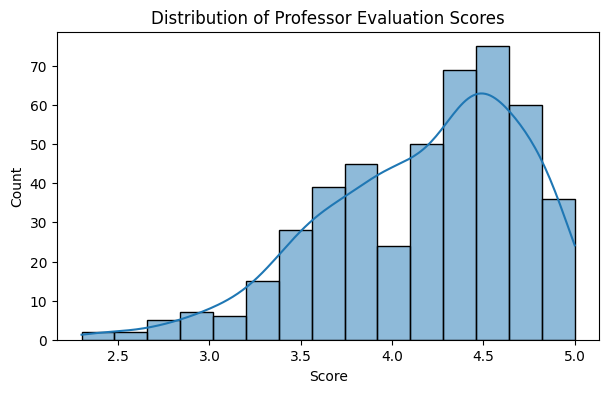

count    463.000000
mean       4.174730
std        0.543865
min        2.300000
25%        3.800000
50%        4.300000
75%        4.600000
max        5.000000
Name: score, dtype: float64
skeeness: -0.7016417277784772


In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(evals_data['score'], bins=15, kde=True)
plt.title('Distribution of Professor Evaluation Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

print(evals_data['score'].describe())
print('skeeness:', evals_data['score'].skew())

The distribution of SCORE is slightly left-skewed. Many scores are clustered near the hisher levels of the 1-5 scale. Suggesting that student give professors positive rateingd.

<div class = 'exercise'>
<h4>Exercise 2</h4>
    Excluding <code>score</code>, select two other variables and describe their relationship using an appropriate visualization (scatterplot, side-by-side boxplots, or mosaic plot).

### Simple linear regression
    The fundamental phenomenon suggested by the study is that better looking teachers are evaluated more favorably. First create a scatterplot to see if this appears to be the case.
</div>

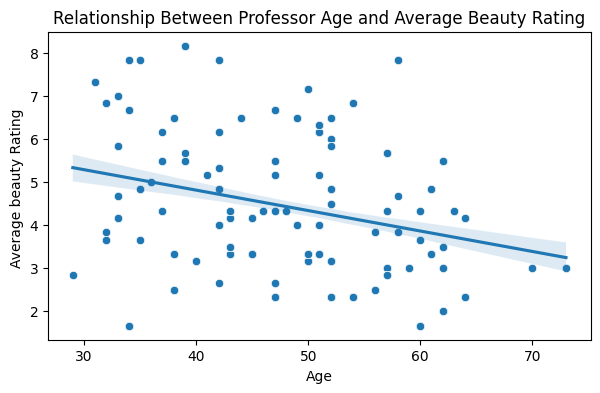

In [ ]:
#Age Vs beauty

plt.figure(figsize=(7,4))
sns.scatterplot(data=evals_data, x='age', y='bty_avg')
sns.regplot(data=evals_data, x='age', y='bty_avg', scatter=False)
plt.title('Relationship Between Professor Age and Average Beauty Rating')
plt.xlabel('Age')
plt.ylabel('Average beauty Rating ')
plt.show()

<div class = 'exercise'>
<h4>Exercise 3</h4>
Let's see if the apparent trend in the plot is something more than natural variation. Fit a linear model called <code>m_bty</code> to predict average professor score by average beauty rating and add the line to your plot. Write out the equation for the linear model and interpret the slope. Is average beauty score a statistically significant predictor? Does it appear to be a practically significant predictor?
</div>

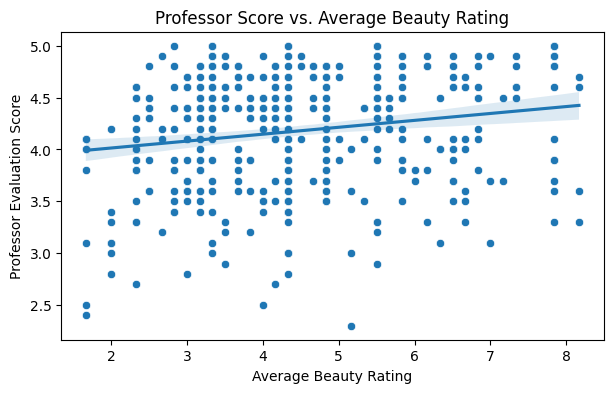

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     16.73
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           5.08e-05
Time:                        00:26:41   Log-Likelihood:                -366.22
No. Observations:                 463   AIC:                             736.4
Df Residuals:                     461   BIC:                             744.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.8803      0.076     50.961      0.0

In [5]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=evals_data, x='bty_avg', y='score')
sns.regplot(data=evals_data, x='bty_avg', y='score', scatter=False)
plt.title('Professor Score vs. Average Beauty Rating')
plt.xlabel('Average Beauty Rating')
plt.ylabel('Professor Evaluation Score')
plt.show()

m_bty = ols('score ~ bty_avg', data=evals_data).fit()
print(m_bty.summary())

Beauty rating is statistically significant because the p-value is less than 0.05. It is not significant because the increase is small and the model shows 3.5 of the variation in scores

<div class = 'exercise'>
<h4>Exercise 4</h4>
Use residual plots to evaluate whether the conditions of least squares regression are reasonable. Provide plots and comments for each one (see the Simple Regression Lab for a reminder of how to make these).
</div>

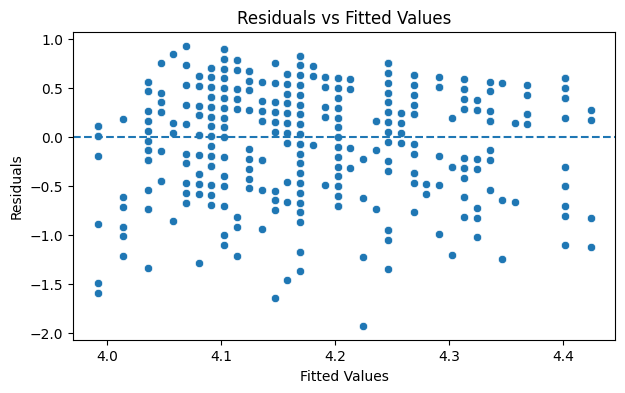

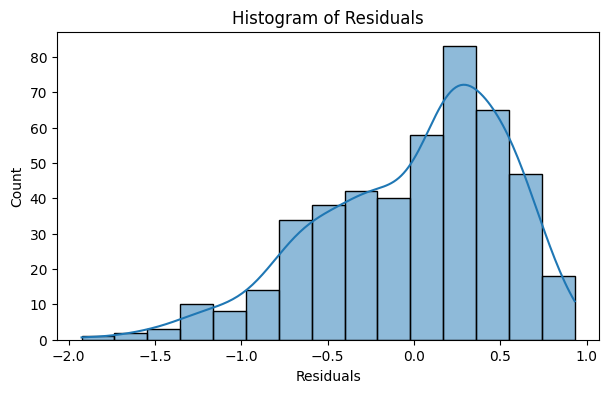

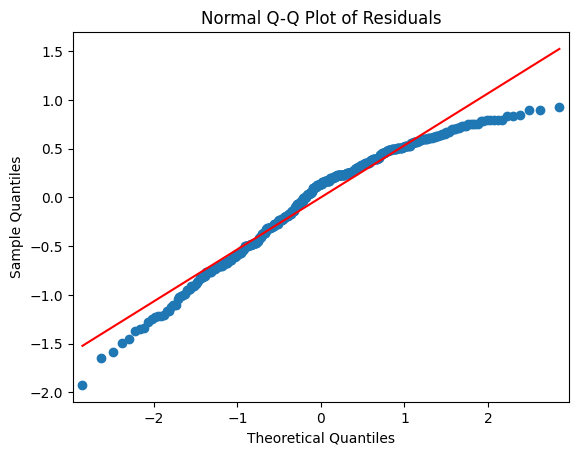

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot

fitted = m_bty.fittedvalues
resid = m_bty.resid

plt.figure(figsize=(7,4))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(resid, bins=15, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.show()

qqplot(resid, line='s')
plt.title('Normal Q-Q Plot of Residuals')
plt.show()

The residuals are mostly scattered around 0, so the linearity condition is reasonable. The residuals are a little left skewed, so the normaility condition is not perfect.

## Multiple linear regression

<div class = 'exercise'>
<h4>Exercise 5</h4>
The data set contains several variables on the beauty score of the professor: individual ratings from each of the six students who were asked to score the physical appearance of the professors and the average of these six scores. Take a look at the relationship between one of these scores and the average beauty score.
</div>



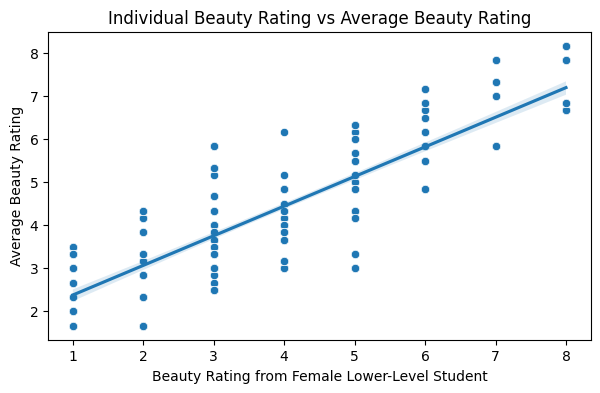

             bty_f1lower   bty_avg
bty_f1lower     1.000000  0.843911
bty_avg         0.843911  1.000000


In [8]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=evals_data, x='bty_f1lower', y='bty_avg')
sns.regplot(data=evals_data, x='bty_f1lower', y='bty_avg', scatter=False)
plt.title('Individual Beauty Rating vs Average Beauty Rating')
plt.xlabel('Beauty Rating from Female Lower-Level Student')
plt.ylabel('Average Beauty Rating')
plt.show()

print(evals_data[['bty_f1lower','bty_avg']].corr())

The relationship is strong and positive. bty_avg is cal using the individual beauty rating variabled

<div class = 'exercise'>
<h4>Exercise 6</h4>
It is expected that you will see the relationship is quite strong - after all, the average score is calculated using the individual scores. We can actually take a look at the relationships between all beauty variables (columns 13 through 19) by plotting pairwise relationships using `pairplot()` function by `seaborn`. Now visualize the pair-wise correlations.
</div>



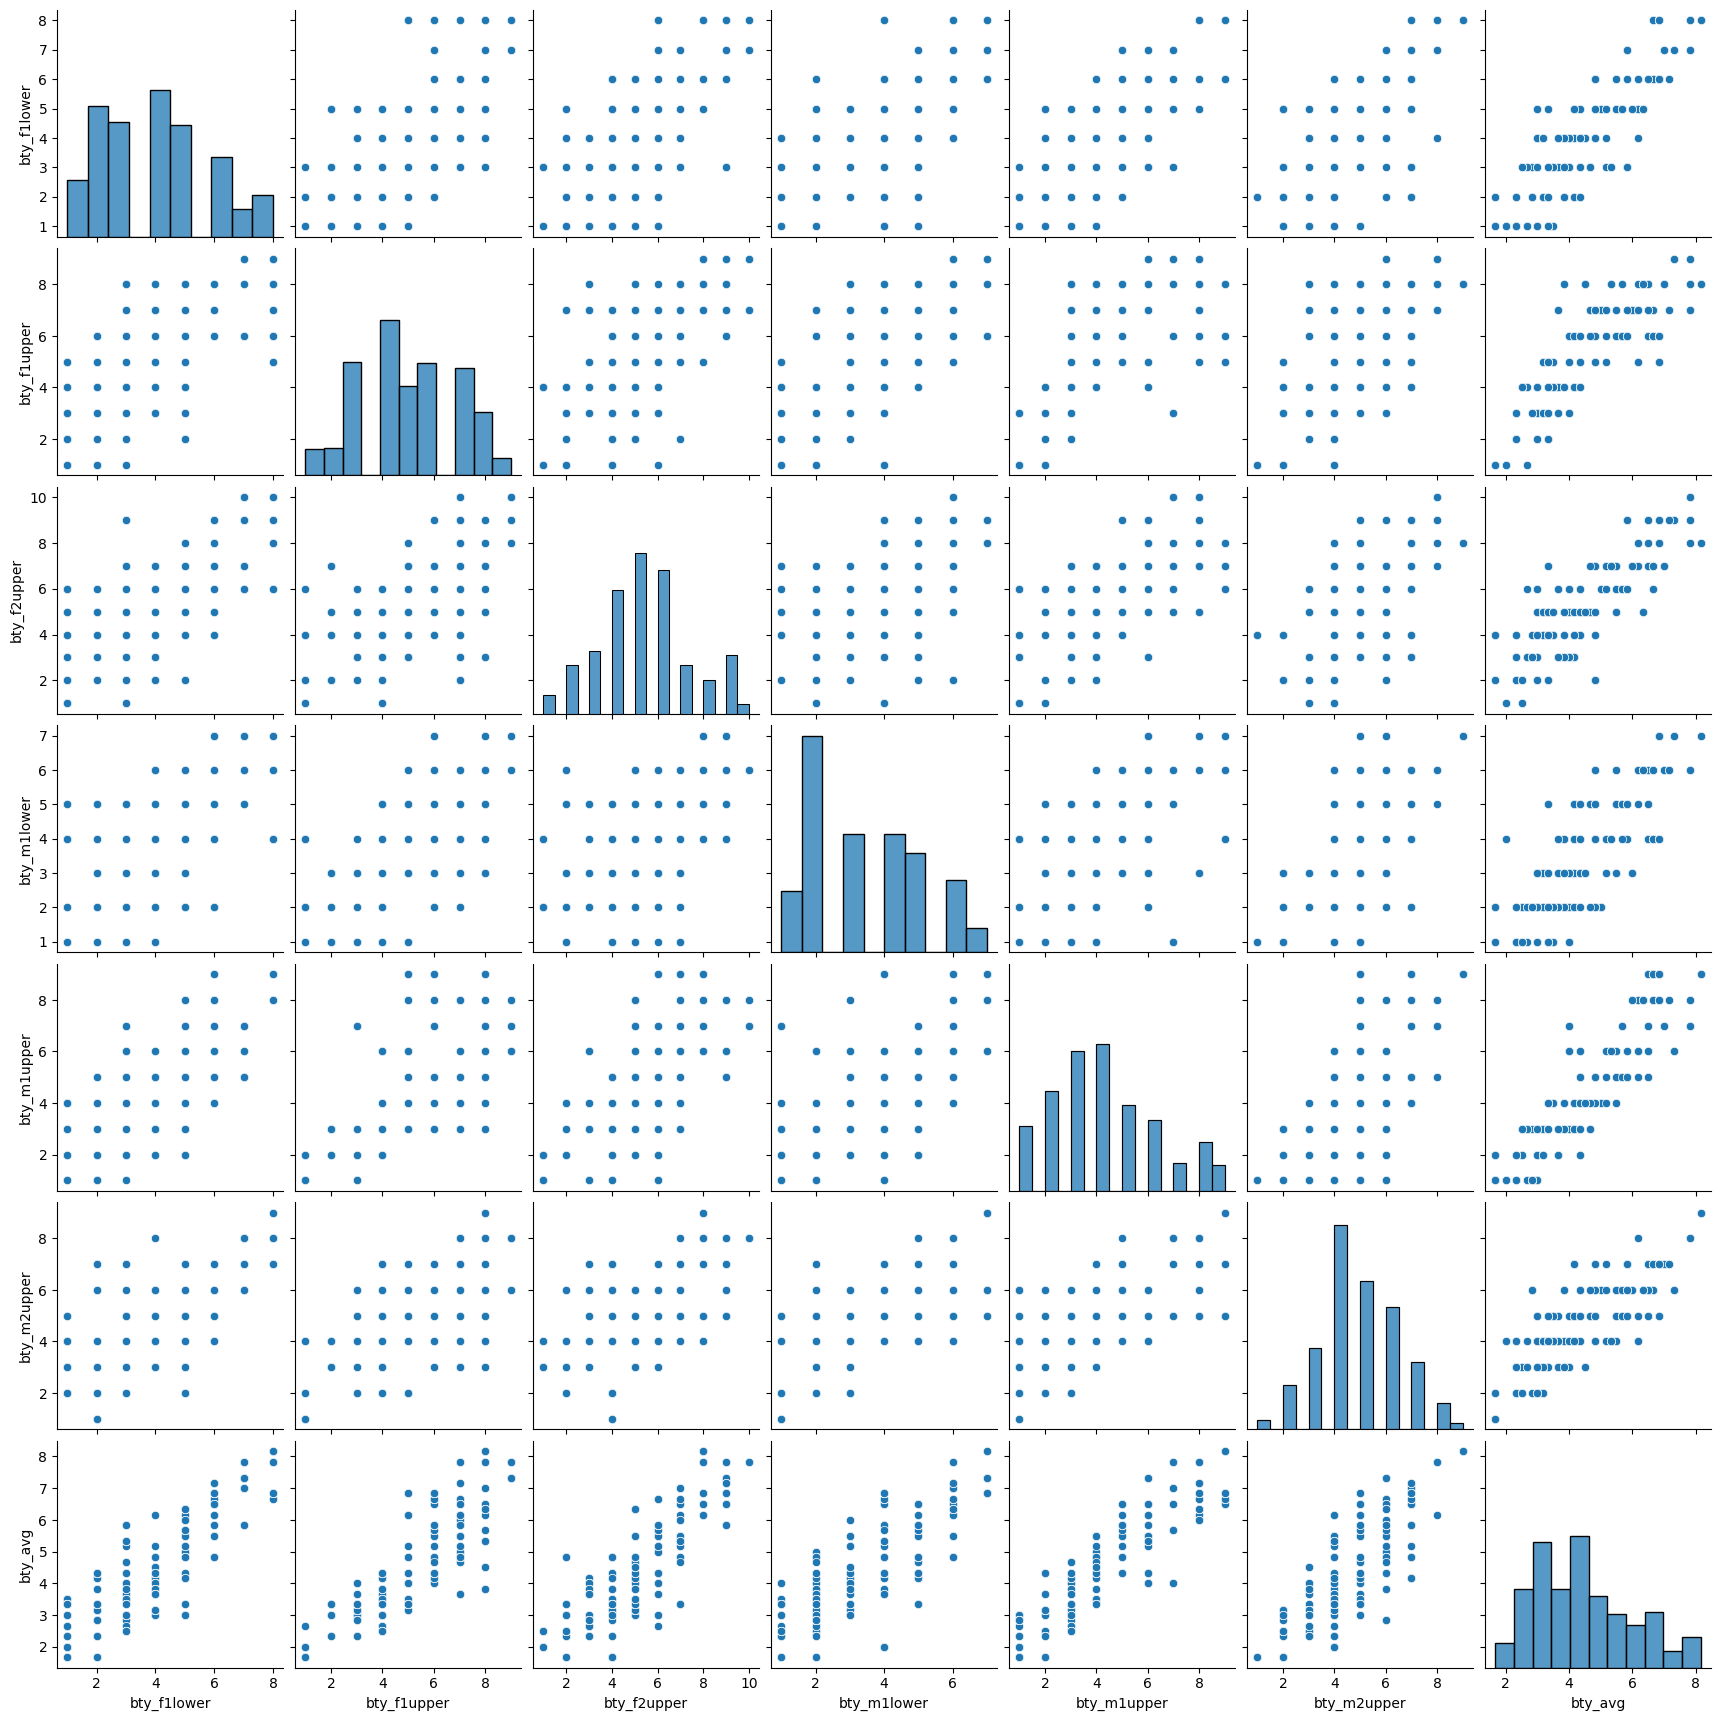

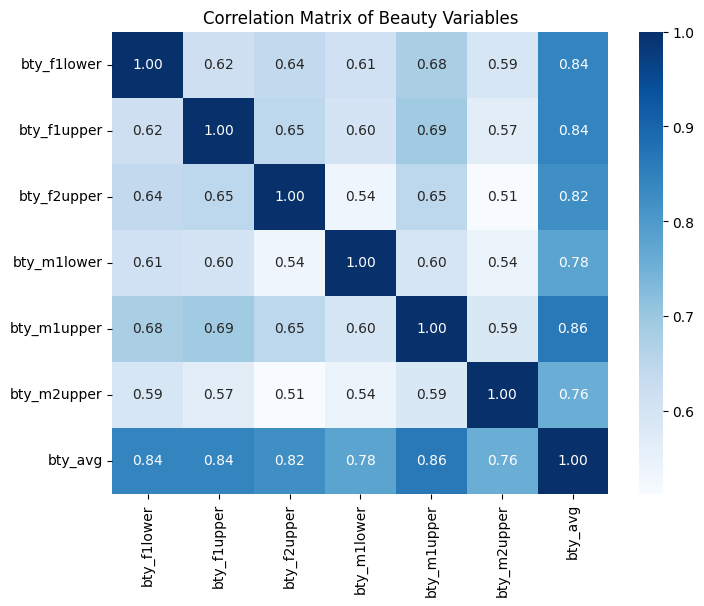

In [9]:
beauty_cols = ['bty_f1lower','bty_f1upper','bty_f2upper','bty_m1lower','bty_m1upper','bty_m2upper','bty_avg']
sns.pairplot(evals_data[beauty_cols])
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(evals_data[beauty_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix of Beauty Variables')
plt.show()

The beauty variables are highlt correlated with each other. it is better to use bty_avg as one representative beauty variable instead of putting all beauty rating into the same model.

These variables are collinear (correlated), and adding more than one of these variables to the model would not add much value to the model. In this application and with these highly-correlated predictors, it is reasonable to use the average beauty score as the single representative of these variables.

In order to see if beauty is still a significant predictor of professor score after we've accounted for the gender of the professor, we can add the gender term into the model.

Since `gender` is a nominal category feature, we first need to convert `gender` from having the values of `female` and `male` to being an indicator variable called `gender_integer` that takes a value of `0` for females and a value of `1` for males (Such variables are often referred to as "dummy" variables.). We can use the `replace()` function for integer-encoding. Before using the `replace()` function, we need define a mapping between the levels and the integers using a dictionary as below.

In [ ]:
level_mapping = {'female': 0, 'male': 1}

Once we define a mapping, we can define a new variable called `gender_integer` and then perform the integer-encoding using the `replace()` function.

In [12]:
level_mapping = {'female': 0, 'male': 1}
gender_integer = evals_data['gender'].copy()
gender_integer = gender_integer.replace(level_mapping)
gender_integer.head(5)
evals_data['gender_integer'] = gender_integer

/tmp/ipykernel_2270/1615701434.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gender_integer = gender_integer.replace(level_mapping)


In [14]:
formula = 'score ~ bty_avg + gender_integer'
model = ols(formula, data=evals_data)
model_fitted = model.fit()
print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     14.45
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           8.18e-07
Time:                        00:35:11   Log-Likelihood:                -360.37
No. Observations:                 463   AIC:                             726.7
Df Residuals:                     460   BIC:                             739.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.7473      0.085     44.

<div class = 'exercise'>
<h4>Exercise 7</h4>
P-values and parameter estimates should only be trusted if the conditions for the regression are reasonable. Verify that the conditions for this model are reasonable using diagnostic plots.
</div>

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     14.45
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           8.18e-07
Time:                        00:37:00   Log-Likelihood:                -360.37
No. Observations:                 463   AIC:                             726.7
Df Residuals:                     460   BIC:                             739.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.7473      0.085     44.

/tmp/ipykernel_2270/1834946023.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  evals_data['gender_integer'] = evals_data['gender'].replace(level_mapping)


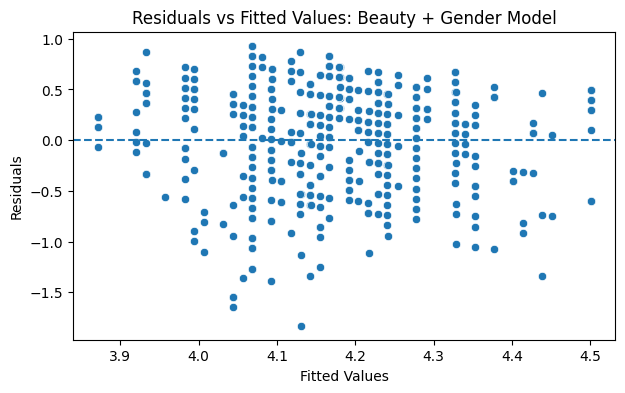

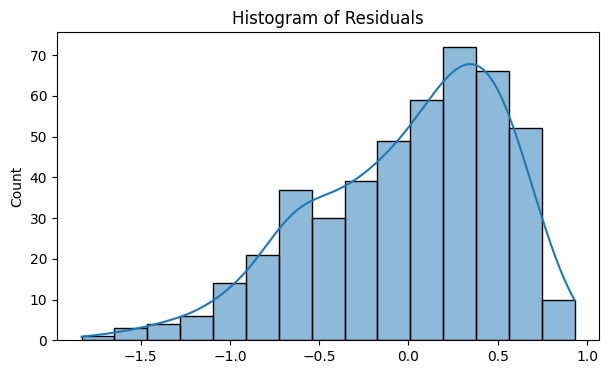

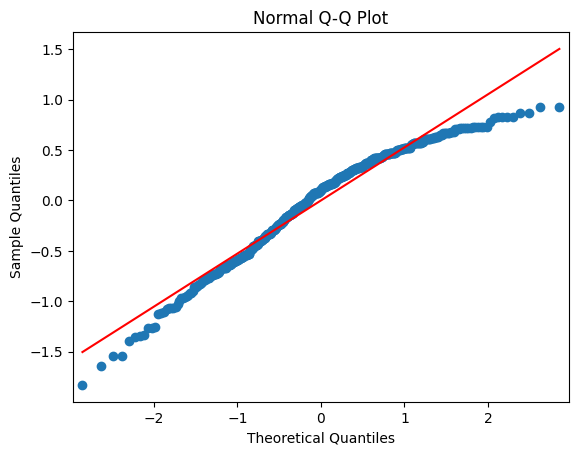

In [15]:
level_mapping = {'female': 0, 'male': 1}
evals_data['gender_integer'] = evals_data['gender'].replace(level_mapping)

m_bty_gender = ols('score ~ bty_avg + gender_integer', data=evals_data).fit()
print(m_bty_gender.summary())

fitted = m_bty_gender.fittedvalues
resid = m_bty_gender.resid

plt.figure(figsize=(7,4))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs Fitted Values: Beauty + Gender Model')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(resid, bins=15, kde=True)
plt.title('Histogram of Residuals')
plt.show()

qqplot(resid, line='s')
plt.title('Normal Q-Q Plot')
plt.show()

THe diagnostic plots look acceptable. The residuals are centered around 0 and there is no strong curved pattern. THe residuals are not normal but the model conditions are enough for interpation.

<div class = 'exercise'>
<h4>Exercise 8</h4>
    Is <code>bty_avg</code> still a significant predictor of <code>score</code>? Has the addition of <code>gender</code> to the model changed the parameter estimate for <code>bty_avg</code>?
</div>

 In the model with gender included, bty_avg is still statistically significant because its p-value is less than 0.05. The beauty coefficient changed from about 0.0666 in the simple model to about 0.0742 in the gender model. Meaning the estimated effect of beauty becomes slightly larger after controlling for gender.

<div class = 'exercise'>
<h4>Exercise 9</h4>
    What is the equation of the line corresponding to males? (<i>Hint</i>: For males, the parameter estimate is multiplied by 1.) For two professors who received the same beauty rating, which gender tends to have the higher course evaluation score?
</div>

score = 3.7473 + 0.0742(bty_avg) + 0.1724(gender_integer)

For males, gender_integer = 1, so:

score = 3.9197 + 0.0742(bty_avg)

For two professors with the same beauty rating, male professors tend to have a higher predicted course evaluation score by about 0.172 points

<div class = 'exercise'>
<h4>Exercise 10</h4>
    Create a new model called <code>m_bty_rank</code> with <code>gender</code>  removed and <code>rank</code>  added in. Note that the rank variable has three levels:  <code>teaching</code> , <code>tenure track</code> , <code>tenured</code> .
</div>

In [16]:
m_bty_rank = ols('score ~ bty_avg + C(rank)', data=evals_data).fit()
print(m_bty_rank.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     7.465
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           6.88e-05
Time:                        00:40:37   Log-Likelihood:                -363.45
No. Observations:                 463   AIC:                             734.9
Df Residuals:                     459   BIC:                             751.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The interpretation of the coefficients in multiple regression is slightly different from that of simple regression. The estimate for `bty_avg` reflects how much higher a group of professors is expected to score if they have a beauty rating that is one point higher *while holding all other variables constant*. In this case, that translates into considering only professors of the same rank with `bty_avg` scores that are one point apart.

This model predicts professor score using average beauty rating and academic rank. teaching is the reference category for rank. The coefficients for tenure track and tenured compare those groups to teaching faculty while holding beauty rating constant.

This model predicts professor score using average beauty rating and academic rank. teaching is the reference category for rank. The coefficients for tenure track and tenured compare those groups to teaching faculty while holding beauty rating constant.



## The search for the best model

We will start with a full model that predicts professor score based on rank, ethnicity, gender, language of the university where they got their degree, age, proportion of students that filled out evaluations, class size, course level, number of professors, number of credits, average beauty rating, outfit, and picture color.

<div class = 'exercise'>
<h4>Exercise 11</h4>
    Which variable would you expect to have the highest p-value in this model? Why? <i>Hint</i>: Think about which variable would you expect to not have any association with the professor score.
</div>

 I would expect variables like pic_outfit, pic_color, or cls_profs to have high p-values because they may not have a strong direct relationship with teaching evaluation score.

<div class = 'exercise'>
<h4>Exercise 12</h4>
Check your suspicions from the previous exercise. Include the model output in your response.
    </div>

In [20]:
full_formula = '''score ~ C(rank) + C(ethnicity) + C(gender) + C(language) + age + cls_perc_eval + cls_students + C(cls_level) + C(cls_profs) + C(cls_credits) + bty_avg + C(pic_outfit) + C(pic_color)'''

full_model = ols(full_formula, data=evals_data).fit()
print(full_model.summary())
print('P-values sorted from highest to lowest:')
print(full_model.pvalues.sort_values(ascending=False))

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     7.366
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           6.55e-14
Time:                        00:45:59   Log-Likelihood:                -326.52
No. Observations:                 463   AIC:                             683.0
Df Residuals:                     448   BIC:                             745.1
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

the variable with the highest p-value is cls_profs,C(cls_profs)[T.single], with a p-value around 0.778.  The class had a single professor or multiple professors is not a useful predictor in this model.

<div class = 'exercise'>
<h4>Exercise 13</h4>
Interpret the coefficient associated with the ethnicity variable.    </div>

minority is the reference group, and not minority has a coefficient of about 0.1235.

Holding the other variables constant, professors listed as not minority are predicted to have evaluation scores about 0.124 points higher than professors listed as minority.

<div class = 'exercise'>
<h4>Exercise 14</h4>
Drop the variable with the highest p-value and re-fit the model. Did the coefficients and significance of the other explanatory variables change? (One of the things that makes multiple regression interesting is that coefficient estimates depend on the other variables that are included in the model.) If not, what does this say about whether or not the dropped variable was collinear with the other explanatory variables?    </div>

In [ ]:
reduced_model = ols('''score ~ C(rank) + C(ethnicity) + C(gender) + C(language) + age + cls_perc_eval + cls_students + C(cls_level) + C(cls_credits) + bty_avg + C(pic_outfit) + C(pic_color)''', data=evals_data).fit()
print(reduced_model.summary())

After dropping cls_profs, the coefficients and significance levels of the other variables do not change very much

<div class = 'exercise'>
<h4>Exercise 15</h4>
Using backward-selection and p-value as the selection criterion, determine the best model. You do not need to show all steps in your answer, just the output for the final model.   
</div>

In [18]:
terms = ['C(rank)', 'C(ethnicity)', 'C(gender)', 'C(language)', 'age', 'cls_perc_eval', 'cls_students', 'C(cls_level)', 'C(cls_profs)', 'C(cls_credits)', 'bty_avg', 'C(pic_outfit)', 'C(pic_color)']

def fit_model(terms):
    return ols('score ~ ' + ' + '.join(terms), data=evals_data).fit()

current_terms = terms.copy()
removed_terms = []

while True:
    model = fit_model(current_terms)
    pvalues = model.pvalues.drop('Intercept')
    max_p = pvalues.max()
    worst_param = pvalues.idxmax()

    if max_p <= 0.05:
        break

    term_to_remove = None
    for term in current_terms:
        if term.startswith('C('):
            var = term[2:-1]
            if worst_param.startswith(f'C({var})'):
                term_to_remove = term
                break
        elif worst_param == term:
            term_to_remove = term
            break

    removed_terms.append((term_to_remove, max_p))
    current_terms.remove(term_to_remove)

final_model = fit_model(current_terms)
print('Removed terms:', removed_terms)
print('Final terms:', current_terms)
print(final_model.summary())

Removed terms: [('C(cls_profs)', 0.7780565665456324), ('C(cls_level)', 0.292200029533535), ('cls_students', 0.31945139958153557), ('C(rank)', 0.20546916040823052), ('C(pic_outfit)', 0.09051020885419658)]
Final terms: ['C(ethnicity)', 'C(gender)', 'C(language)', 'age', 'cls_perc_eval', 'C(cls_credits)', 'bty_avg', 'C(pic_color)']
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     11.80
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           2.58e-15
Time:                        00:45:08   Log-Likelihood:                -330.74
No. Observations:                 463   AIC:                             679.5
Df Residuals:                     454   BIC:                             716.7
Df Model:                           8

 Using backward selection with p-value as the criterion, the final model includes ethnicity, gender, language, age, percent of students who completed evaluations, class credits, average beauty rating, and picture color.



<div class = 'exercise'>
<h4>Exercise 16</h4>
Also, write out the linear model for predicting score based on the final model you settle on.    
</div>

score = 3.7719 + 0.1679(not minority) + 0.2071(male) - 0.2062(non-English language) + 0.5053(one credit) - 0.1906(color picture) - 0.0060(age) + 0.0047(cls_perc_eval) + 0.0511(bty_avg)

<div class = 'exercise'>
<h4>Exercise 17</h4>
Verify that the conditions for this model are reasonable using diagnostic plots.    </div>

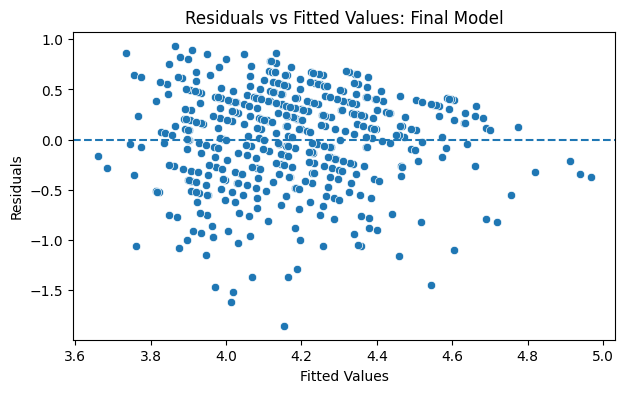

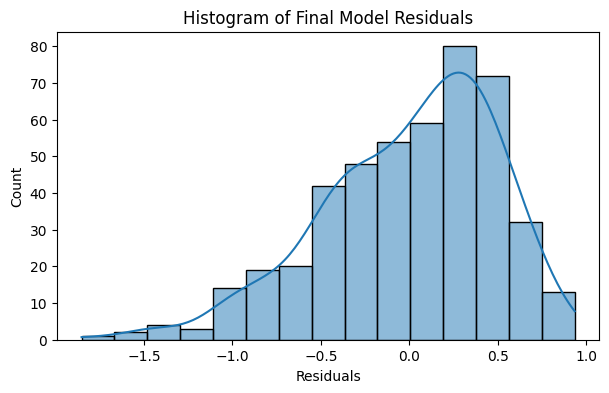

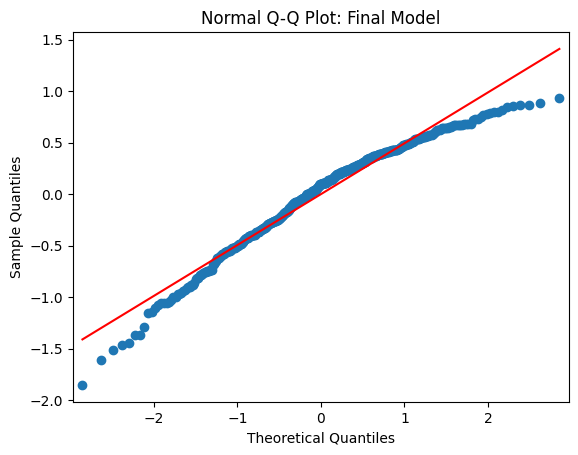

In [21]:
fitted = final_model.fittedvalues
resid = final_model.resid

plt.figure(figsize=(7,4))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs Fitted Values: Final Model')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

plt.figure(figsize=(7,4))
sn = sns.histplot(resid, bins=15, kde=True)
plt.title('Histogram of Final Model Residuals')
plt.xlabel('Residuals')
plt.show()

qqplot(resid, line='s')
plt.title('Normal Q-Q Plot: Final Model')
plt.show()

he residual plots show that the final model is reasonably acceptable. The residuals are mostly centered around 0, and there is no strong curved pattern. The residuals are somewhat left-skewed

The residual plots show that the final model is reasonably acceptable

The residuals are mostly centered around 0, and there is no strong curved pattern. The residuals are somewhat left-skewed

<div class = 'exercise'>
<h4>Exercise 18</h4>
The original paper describes how these data were gathered by taking a sample of professors from the University of Texas at Austin and including all courses that they have taught. Considering that each row represents a course, could this new information have an impact on any of the conditions of linear regression?    </div>

each row is a course and some professors appear more than once, the observations may not be fully independent. Courses taught by the same professor may receive similar scores because they share the same instructor. This could violate the independence condition of linear regression. A mixed-effects model with professor as a random effect could better account for repeated courses taught by the same professor.

<div class = 'exercise'>
<h4>Exercise 19</h4>
Based on your final model, describe the characteristics of a professor and course at University of Texas at Austin that would be associated with a high evaluation score.    </div>

Based on the final model, higher evaluation scores are associated with professors who have higher average beauty ratings, are male, are not minority, received their education in English, are younger, teach one-credit courses, and have a higher percentage of students completing evaluations. The model also suggests that black-and-white picture status is associated with higher predicted scores compared with color picture status, though this may reflect the way the dataset is coded rather than a meaningful teaching-related factor.

<div class = 'exercise'>
<h4>Exercise 20</h4>
Would you be comfortable generalizing your conclusions to apply to professors generally (at any university)? Why or why not?</div>

 I would not be fully comfortable generalizing these results to all professors at all universities. The data came from one university, the University of Texas at Austin, and the study used a specific sample of professors and courses. Other universities may have different student populations, course structures, evaluation systems, and instructor characteristics. The results are useful for understanding this dataset, but broader conclusions would require data from more universities.